In [2]:
import os, glob, random, json, time, gc
import numpy as np
import cv2
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from mealpy import FloatVar, PSO
from scipy.ndimage import distance_transform_edt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

IMG_SIZE   = 256                       
CLASSES    = ['benign', 'malignant']   
SEED       = 42
BATCH_SIZE = 2
BUSI_ROOT  = "/Users/mariyamafnan/Documents/MVI/Dataset_BUSI_with_GT"
SMOOTH     = 1e-6
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [3]:
def robust_imread_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None: return img
    return np.array(Image.open(path).convert('L'))

def find_busi_pairs(root_dir):
    rows = []
    for cls in CLASSES:
        for img_path in sorted(glob.glob(os.path.join(root_dir, cls, '*.png'))):
            if '_mask' in os.path.basename(img_path): continue
            masks = sorted(glob.glob(os.path.splitext(img_path)[0] + '_mask*.png'))
            if masks: rows.append({'image': img_path, 'masks': masks, 'class': cls})
    return pd.DataFrame(rows)

def merge_masks(mask_paths):
    combined = None
    for mp in mask_paths:
        m = (robust_imread_gray(mp) > 127).astype(np.uint8)
        combined = m if combined is None else np.maximum(combined, m)
    return combined

def resize_with_padding(arr, size=IMG_SIZE, is_mask=False):
    h, w = arr.shape[:2]; scale = size / max(h, w)
    nh, nw = int(round(h*scale)), int(round(w*scale))
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
    resized = cv2.resize(arr, (nw, nh), interpolation=interp)
    canvas = np.zeros((size, size), dtype=arr.dtype)
    top, left = (size-nh)//2, (size-nw)//2
    canvas[top:top+nh, left:left+nw] = resized
    return canvas

def load_pair(row, size=IMG_SIZE):
    img  = resize_with_padding(robust_imread_gray(row['image']), size).astype(np.float32)[..., None]/255.0
    mask = resize_with_padding(merge_masks(row['masks']), size, is_mask=True).astype(np.float32)[..., None]
    return img, mask

In [4]:
def augment_pair(img, mask, rng):
    if rng.random() < 0.5: img, mask = np.fliplr(img), np.fliplr(mask)
    if rng.random() < 0.5: img, mask = np.flipud(img), np.flipud(mask)
    angle, scale = rng.uniform(-20, 20), rng.uniform(0.9, 1.15)
    M = cv2.getRotationMatrix2D((IMG_SIZE/2, IMG_SIZE/2), angle, scale)
    img  = cv2.warpAffine(img,  M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_AREA,   borderMode=cv2.BORDER_CONSTANT)
    mask = cv2.warpAffine(mask, M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    if img.ndim == 2:  img = img[..., None]
    if mask.ndim == 2: mask = mask[..., None]
    if rng.random() < 0.5: img = np.clip(img * rng.uniform(0.8, 1.2), 0, 1)
    return img.astype(np.float32), (mask > 0.5).astype(np.float32)

class BUSISequence(keras.utils.Sequence):
    def __init__(self, df, batch_size=BATCH_SIZE, augment=False, augment_factor=1, shuffle=True, seed=SEED):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.augment_factor = augment_factor if augment else 1
        self.shuffle = shuffle
        self.rng = random.Random(seed)
        self.indices = np.repeat(np.arange(len(self.df)), self.augment_factor)
        self.cache = [load_pair(self.df.iloc[i]) for i in range(len(self.df))]
        self.on_epoch_end()
    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))
    def on_epoch_end(self):
        if self.shuffle:
            np.random.RandomState(self.rng.randint(0, 1 << 30)).shuffle(self.indices)
    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, masks = [], []
        for i in batch_idx:
            img, mask = self.cache[i]
            if self.augment: img, mask = augment_pair(img, mask, self.rng)
            imgs.append(img); masks.append(mask)
        return np.stack(imgs), np.stack(masks)

In [5]:
df = find_busi_pairs(BUSI_ROOT)
df = df[df['class'] != 'normal'].reset_index(drop=True)
print('tumour images found:', len(df), df['class'].value_counts().to_dict())

tumour images found: 647 {'benign': 437, 'malignant': 210}


In [6]:
 #===================== FULL CURATION (self-contained): sim + axilla + dedup + split =====================
import os

# ---- compute similarity matrix ----
names = [os.path.basename(p) for p in df['image']]
_vecs = []
for p in df['image']:
    im = cv2.resize(robust_imread_gray(p), (64, 64)).astype(np.float32)
    im = (im - im.mean()) / (im.std() + 1e-6)
    _vecs.append(im.flatten())
mat = np.stack(_vecs)
mat = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-6)
sim = mat @ mat.T

# ---- axilla images (manually verified) ----
AXILLA_MANUAL = [
    "benign (199).png", "benign (205).png", "benign (207).png", "benign (210).png",
    "benign (223).png", "benign (225).png", "benign (228).png","benign (416).png", "benign (235).png",
    "benign (236).png", "benign (243).png", "benign (247).png", "benign (248).png",
    "benign (256).png", "benign (257).png", "benign (262).png", "benign (292).png",
    "benign (293).png", "benign (294).png", "benign (298).png", "benign (306).png",
    "malignant (11).png", "malignant (12).png", "malignant (13).png", "malignant (109).png",
    "malignant (110).png", "malignant (113).png", "malignant (148).png",
]
axilla = set(AXILLA_MANUAL)
print(f"Excluding {len(axilla)} manually-verified axilla images")

THRESH = 0.886
# ---- dedup (threshold 0.886 + manual overrides) ----
MANUAL_DUP = [
    ("benign (201).png", "benign (302).png"),
    ("malignant (7).png", "malignant (8).png"),
    ("malignant (8).png", "malignant (9).png"),
    ("benign (64).png", "benign (141).png"),
]
MANUAL_KEEP = [
    ("malignant (3).png", "malignant (7).png"),
    ("malignant (24).png", "malignant (25).png"),
]
# images wrongly flagged as duplicates by the threshold — force-keep them
FORCE_KEEP = {
    "malignant (50).png", "malignant (72).png",
    "malignant (40).png", "malignant (6).png",
    "benign (435).png", "malignant (4).png"                         
}

keep_apart = {frozenset(p) for p in MANUAL_KEEP}
parent = {n: n for n in names}
def find(x):
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    if a in parent and b in parent: parent[find(a)] = find(b)

for i in range(len(names)):
    for j in range(i+1, len(names)):
        if sim[i, j] > THRESH and frozenset({names[i], names[j]}) not in keep_apart:
            union(names[i], names[j])
for a, b in MANUAL_DUP:
    union(a, b)

groups = {}
for n in names: groups.setdefault(find(n), []).append(n)
keep_dedup = {sorted(g)[0] for g in groups.values()}

# ---- final: deduped minus axilla ----
keep = keep_dedup - axilla
print(f"{len(names)} -> {len(keep)} after curation "
      f"({len(names)-len(keep_dedup)} dups + {len(keep_dedup & axilla)} axilla removed)")

df = df[df['image'].apply(lambda p: os.path.basename(p) in keep)].reset_index(drop=True)
print(df['class'].value_counts().to_string())

Excluding 28 manually-verified axilla images
647 -> 509 after curation (117 dups + 21 axilla removed)
class
benign       329
malignant    180


In [7]:
trainval_df, test_df = train_test_split(df, test_size=0.20, stratify=df['class'], random_state=SEED)
trainval_df = trainval_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)
tvs = trainval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
nv = int(len(tvs)*0.15)
train_df, val_df = tvs.iloc[nv:].reset_index(drop=True), tvs.iloc[:nv].reset_index(drop=True)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

train_gen = BUSISequence(train_df, batch_size=BATCH_SIZE, augment=True,  augment_factor=1, shuffle=True)
val_gen   = BUSISequence(val_df,   batch_size=BATCH_SIZE, augment=False)

train 346 | val 61 | test 102


In [8]:
def dice_coef(y_true, y_pred):
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt*yp)
    return (2.*inter + SMOOTH) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + SMOOTH)
def dice_loss(y_true, y_pred): return 1 - dice_coef(y_true, y_pred)
def hybrid_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)
def iou_coef(y_true, y_pred):
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt*yp); union = tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter
    return (inter + SMOOTH) / (union + SMOOTH)

In [9]:
def gn(x):
    c = x.shape[-1]
    g = 8 if c % 8 == 0 else (4 if c % 4 == 0 else 1)
    return layers.GroupNormalization(groups=g)(x)

def residual_block(x, filters, activation='relu'):
    # Fig. 2:  Conv-Norm-ReLU-Conv-Norm  +  shortcut(Conv-Norm)  -> Add -> ReLU
    shortcut = x
    y = layers.Conv2D(filters, 3, padding='same')(x)
    y = gn(y)
    y = layers.Activation(activation)(y)
    y = layers.Conv2D(filters, 3, padding='same')(y)
    y = gn(y)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = gn(shortcut)
    y = layers.Add()([y, shortcut])
    return layers.Activation(activation)(y)

def build_benchmark_unet(hp, img_size=IMG_SIZE):
    f, act, drop = hp['filters'], hp['activation'], hp['dropout']
    inputs = layers.Input((img_size, img_size, 1))
    skips = []; x = inputs

    # ---- Encoder: residual blocks + max-pooling ----
    for i in range(4):
        skip = residual_block(x, f * (2**i), act)
        skip = layers.Dropout(drop)(skip)
        skips.append(skip)
        x = layers.MaxPooling2D(2)(skip)

    # ---- Bottleneck ----
    x = residual_block(x, f * 16, act)
    x = layers.Dropout(drop)(x)

    # ---- Decoder: transpose-conv up + concat skip + residual block  (NO attention) ----
    for i in reversed(range(4)):
        fi = f * (2**i)
        x = layers.Conv2DTranspose(fi, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skips[i]])
        x = residual_block(x, fi, act)
        x = layers.Dropout(drop)(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    model = Model(inputs, outputs, name='residual_unet_benchmark')
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(hp['lr'], clipnorm=1.0),
                  loss=hybrid_loss, metrics=[dice_coef, iou_coef])
    return model

In [10]:
TUNE_SIZE, N_TUNE_TRAIN, N_TUNE_VAL = 96, 120, 40
def load_pair_small(row, size=TUNE_SIZE):
    img  = resize_with_padding(robust_imread_gray(row['image']), size).astype(np.float32)[..., None]/255.0
    mask = resize_with_padding(merge_masks(row['masks']), size, is_mask=True).astype(np.float32)[..., None]
    return img, mask

tune_train_df = train_df.sample(n=min(N_TUNE_TRAIN, len(train_df)), random_state=SEED)
tune_val_df   = val_df.sample(n=min(N_TUNE_VAL, len(val_df)), random_state=SEED)
X_tr  = np.stack([load_pair_small(r)[0] for _, r in tune_train_df.iterrows()])
Y_tr  = np.stack([load_pair_small(r)[1] for _, r in tune_train_df.iterrows()])
X_val = np.stack([load_pair_small(r)[0] for _, r in tune_val_df.iterrows()])
Y_val = np.stack([load_pair_small(r)[1] for _, r in tune_val_df.iterrows()])

ACTIVATIONS = ['relu', 'elu', 'leaky_relu']
def decode(solution):
    filters = max(16, min(64, int(round(solution[0]/8)*8)))
    dropout = float(np.clip(solution[1], 0.0, 0.5))
    act = ACTIVATIONS[int(np.clip(round(solution[2]), 0, 2))]
    lr = float(10 ** solution[3])
    return {'filters': filters, 'dropout': dropout, 'activation': act, 'lr': lr}

# build a reference once to normalise param count
_ref = build_benchmark_unet({'filters':16,'dropout':0.3,'activation':'relu','lr':1e-3}, img_size=TUNE_SIZE)
REF_PARAMS = _ref.count_params(); keras.backend.clear_session()

def pso_objective(solution):
    hp = decode(solution)
    m = build_benchmark_unet(hp, img_size=TUNE_SIZE)
    params = m.count_params()
    m.fit(X_tr, Y_tr, validation_data=(X_val, Y_val), epochs=6, batch_size=8, verbose=0)
    val_dice = m.evaluate(X_val, Y_val, batch_size=8, verbose=0)[1]
    del m; keras.backend.clear_session(); gc.collect()
    return (1.0 - val_dice) + 0.15 * (params / REF_PARAMS)   # size penalty -> favours generalisable models

problem = {'obj_func': pso_objective,
           'bounds': FloatVar(lb=[16, 0.0, 0, -5], ub=[24, 0.5, 2.99, -3], name='benchmark_hp'),
           'minmax': 'min', 'log_to': None}
POP_SIZE, EPOCHS = 5, 3
t0 = time.time()
g_best = PSO.OriginalPSO(epoch=EPOCHS, pop_size=POP_SIZE).solve(problem)
tuning_time = time.time() - t0
best_hp = decode(g_best.solution)
print('best hyperparameters:', best_hp)
print('best val dice during search:', 1 - g_best.target.fitness, '| tuning time (s):', tuning_time)

2026-09-08 22:22:06.755758: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-09-08 22:22:06.756393: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-08 22:22:06.756934: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-08 22:22:06.758023: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-08 22:22:06.759156: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-08 22:22:13.330427: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-08 22:22:25.232406: I te

best hyperparameters: {'filters': 16, 'dropout': 0.2608110498692136, 'activation': 'elu', 'lr': 0.0002983348211426744}
best val dice during search: 0.4355308175086975 | tuning time (s): 1131.4703741073608


In [11]:
# ===================== Cell 10 - Final training (small model + regularisation) =====================
train_gen = BUSISequence(train_df, batch_size=BATCH_SIZE, augment=True, augment_factor=2, shuffle=True)

final_model = build_benchmark_unet(best_hp, img_size=IMG_SIZE)
callbacks = [
    EarlyStopping(monitor='val_dice_coef', mode='max', patience=12, restore_best_weights=True, start_from_epoch=20),
    ReduceLROnPlateau(monitor='val_dice_coef', mode='max', factor=0.5, patience=4),
]
history = final_model.fit(train_gen, validation_data=val_gen, epochs=60, callbacks=callbacks, verbose=1)
final_model.save('benchmark_unet.keras')
with open('benchmark_unet_tuning_log.json', 'w') as f:
    json.dump({'best_hp': best_hp, 'note': 'filters capped to fix overfitting'}, f, indent=2)
print('saved benchmark_unet.keras')

Epoch 1/60


2026-09-08 22:43:25.217963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


346/346 [==============================] - ETA: 0s - loss: 1.0356 - dice_coef: 0.2725 - iou_coef: 0.1668

2026-09-08 22:50:30.137237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


346/346 [==============================] - 440s 1s/step - loss: 1.0356 - dice_coef: 0.2725 - iou_coef: 0.1668 - val_loss: 0.8203 - val_dice_coef: 0.4185 - val_iou_coef: 0.2746 - lr: 2.9833e-04
Epoch 2/60
346/346 [==============================] - 202s 581ms/step - loss: 0.8437 - dice_coef: 0.3929 - iou_coef: 0.2559 - val_loss: 0.7415 - val_dice_coef: 0.5062 - val_iou_coef: 0.3494 - lr: 2.9833e-04
Epoch 3/60
346/346 [==============================] - 134s 385ms/step - loss: 0.7845 - dice_coef: 0.4397 - iou_coef: 0.2972 - val_loss: 0.6199 - val_dice_coef: 0.5883 - val_iou_coef: 0.4266 - lr: 2.9833e-04
Epoch 4/60
346/346 [==============================] - 134s 386ms/step - loss: 0.7125 - dice_coef: 0.4930 - iou_coef: 0.3443 - val_loss: 0.6294 - val_dice_coef: 0.5899 - val_iou_coef: 0.4287 - lr: 2.9833e-04
Epoch 5/60
346/346 [==============================] - 129s 373ms/step - loss: 0.6690 - dice_coef: 0.5253 - iou_coef: 0.3751 - val_loss: 0.5995 - val_dice_coef: 0.6061 - val_iou_coef: 0.4

In [12]:
def numpy_dice(y_true, y_pred, thresh=0.5):
    yt, yp = (y_true>thresh).astype(np.uint8), (y_pred>thresh).astype(np.uint8)
    inter = np.sum(yt*yp); return (2*inter+SMOOTH)/(np.sum(yt)+np.sum(yp)+SMOOTH)
def numpy_iou(y_true, y_pred, thresh=0.5):
    yt, yp = (y_true>thresh).astype(np.uint8), (y_pred>thresh).astype(np.uint8)
    inter = np.sum(yt*yp); union = np.sum(yt)+np.sum(yp)-inter; return (inter+SMOOTH)/(union+SMOOTH)
def numpy_accuracy(y_true, y_pred, thresh=0.5):
    return np.mean((y_true>thresh).astype(np.uint8) == (y_pred>thresh).astype(np.uint8))
def numpy_precision_recall(y_true, y_pred, thresh=0.5):
    yt, yp = (y_true>thresh).astype(np.uint8), (y_pred>thresh).astype(np.uint8)
    tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
    return tp/(tp+fp+SMOOTH), tp/(tp+fn+SMOOTH)
def hd95(y_true, y_pred, thresh=0.5):
    yt=(y_true.squeeze()>thresh).astype(np.uint8); yp=(y_pred.squeeze()>thresh).astype(np.uint8)
    if yt.sum()==0 and yp.sum()==0: return 0.0
    if yt.sum()==0 or yp.sum()==0: return np.nan
    dt,dp = distance_transform_edt(1-yt), distance_transform_edt(1-yp)
    return np.percentile(np.concatenate([dt[yp.astype(bool)], dp[yt.astype(bool)]]), 95)

In [13]:
def tta_predict(model, img):
    v = [img, np.fliplr(img), np.flipud(img), np.fliplr(np.flipud(img))]
    p = [model.predict(x[None, ...], verbose=0)[0][..., 0] for x in v]
    p[1] = np.fliplr(p[1]); p[2] = np.flipud(p[2]); p[3] = np.flipud(np.fliplr(p[3]))
    return np.mean(p, axis=0)[..., None]          # (H,W,1) to match the metric functions

results = []
for i in range(len(test_df)):
    row = test_df.iloc[i]
    img, gt = load_pair(row)
    pred = tta_predict(final_model, img)           # <-- TTA now, matches innovation
    prec, rec = numpy_precision_recall(gt, pred)
    results.append({'image': os.path.basename(row['image']), 'class': row['class'],
                    'dice': numpy_dice(gt, pred), 'iou': numpy_iou(gt, pred),
                    'accuracy': numpy_accuracy(gt, pred), 'precision': prec, 'recall': rec,
                    'hd95': hd95(gt, pred)})

results_df = pd.DataFrame(results)
print(results_df[['dice','iou','accuracy','precision','recall']].mean())
print('mean Dice:', results_df['dice'].mean(), '± std:', results_df['dice'].std())
print('mean HD95:', results_df['hd95'].mean())
print(results_df.groupby('class')[['dice','iou']].mean())
results_df.to_csv('benchmark_unet_test_results.csv', index=False)

2026-09-09 00:42:03.774272: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


dice         0.784064
iou          0.681720
accuracy     0.957049
precision    0.757942
recall       0.883947
dtype: float64
mean Dice: 0.7840639033790037 ± std: 0.20479397033044466
mean HD95: 18.87431071671996
               dice       iou
class                        
benign     0.825029  0.731216
malignant  0.708962  0.590978


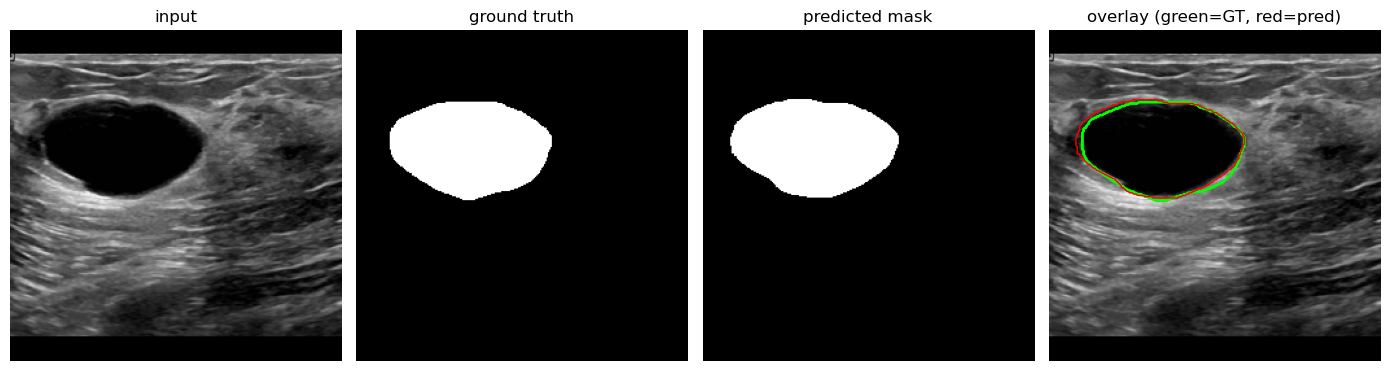

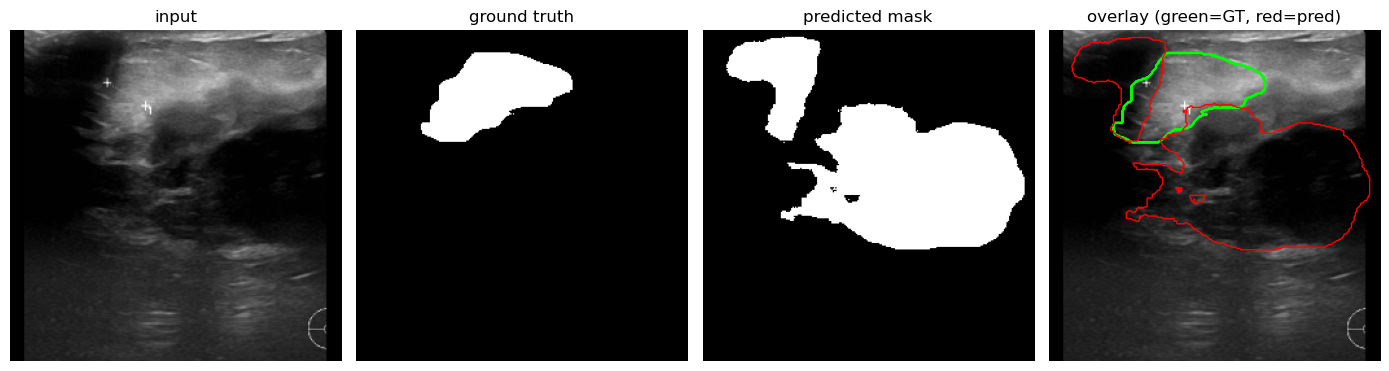

In [14]:
def show_example(row, model):
    img, gt = load_pair(row); pred = model.predict(img[None, ...], verbose=0)[0]
    fig, ax = plt.subplots(1, 4, figsize=(14, 4))
    ax[0].imshow(img.squeeze(), cmap='gray'); ax[0].set_title('input')
    ax[1].imshow(gt.squeeze(), cmap='gray'); ax[1].set_title('ground truth')
    ax[2].imshow(pred.squeeze()>0.5, cmap='gray'); ax[2].set_title('predicted mask')
    ax[3].imshow(img.squeeze(), cmap='gray')
    ax[3].contour(gt.squeeze(), colors='lime', linewidths=1)
    ax[3].contour(pred.squeeze()>0.5, colors='red', linewidths=1)
    ax[3].set_title('overlay (green=GT, red=pred)')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

show_example(test_df.iloc[results_df['dice'].idxmax()], final_model)
show_example(test_df.iloc[results_df['dice'].idxmin()], final_model)

In [16]:
# ---- Benchmark: full hyperparameter check ----
print("=== PSO-TUNED (best_hp) ===")
for k, v in best_hp.items():
    print(f"  {k:12s}: {v}")

print("\n=== FIXED SETTINGS ===")
print(f"  image size     : {IMG_SIZE} x {IMG_SIZE}")
print(f"  batch size     : {BATCH_SIZE}")
print(f"  epochs (max)   : 60")
try:
    print(f"  epochs trained : {len(history.history['loss'])}  (EarlyStopping)")
except NameError:
    print("  epochs trained : (run after training to see this)")
print(f"  augment factor : 2 (training only)")
print(f"  loss           : hybrid BCE + Dice")
print(f"  optimiser      : Adam (clipnorm=1.0)")
print(f"  early stopping : monitor val_dice_coef, patience 12, start epoch 20, restore best")
print(f"  LR schedule    : ReduceLROnPlateau (factor 0.5, patience 4)")
print(f"  kernels        : 3x3 conv, 1x1 shortcut, 2x2 max-pool, 2x2 transpose-conv")

print("\n=== MODEL ===")
m = build_benchmark_unet(best_hp, img_size=IMG_SIZE)
enc_filters = [best_hp['filters'] * (2**i) for i in range(4)]
print(f"  encoder filters: {enc_filters}  | bottleneck: {best_hp['filters']*16}")
print(f"  total params   : {m.count_params():,}")
del m

=== PSO-TUNED (best_hp) ===
  filters     : 16
  dropout     : 0.2608110498692136
  activation  : elu
  lr          : 0.0002983348211426744

=== FIXED SETTINGS ===
  image size     : 256 x 256
  batch size     : 2
  epochs (max)   : 60
  epochs trained : 45  (EarlyStopping)
  augment factor : 2 (training only)
  loss           : hybrid BCE + Dice
  optimiser      : Adam (clipnorm=1.0)
  early stopping : monitor val_dice_coef, patience 12, start epoch 20, restore best
  LR schedule    : ReduceLROnPlateau (factor 0.5, patience 4)
  kernels        : 3x3 conv, 1x1 shortcut, 2x2 max-pool, 2x2 transpose-conv

=== MODEL ===
  encoder filters: [16, 32, 64, 128]  | bottleneck: 256
  total params   : 2,033,025


In [17]:
import numpy as np, cv2
import pandas as pd

# ---- 1) exact disjointness: no identical image in train/val and test ----
train_imgs = set(train_df['image'])
val_imgs   = set(val_df['image'])
test_imgs  = set(test_df['image'])

print("train:", len(train_imgs), "| val:", len(val_imgs), "| test:", len(test_imgs))
print("train ∩ test :", len(train_imgs & test_imgs))
print("val ∩ test   :", len(val_imgs & test_imgs))
print("train ∩ val  :", len(train_imgs & val_imgs))
assert train_imgs.isdisjoint(test_imgs) and val_imgs.isdisjoint(test_imgs), "LEAK!"
print("✓ No identical image appears in both training and test\n")

# ---- 2) stronger: no NEAR-duplicate of any test image is in train/val ----
def vec(path):
    im = cv2.resize(robust_imread_gray(path), (64, 64)).astype(np.float32)
    im = (im - im.mean()) / (im.std() + 1e-6)
    v = im.flatten()
    return v / (np.linalg.norm(v) + 1e-6)

test_vecs = np.stack([vec(p) for p in test_df['image']])
tv_vecs   = np.stack([vec(p) for p in pd.concat([train_df, val_df])['image']])
sims = test_vecs @ tv_vecs.T                    # cosine sim: each test image vs every train/val image
max_sim = sims.max(axis=1)

print(f"Highest test-vs-train cosine similarity: {max_sim.max():.3f}")
print(f"Test images with any train/val match > 0.886 (dedup threshold): {(max_sim > 0.886).sum()} / {len(test_df)}")
print("✓ No near-duplicate of a test image exists in training/validation" if (max_sim <= 0.886).all()
      else "⚠ near-duplicate leakage detected")

train: 346 | val: 61 | test: 102
train ∩ test : 0
val ∩ test   : 0
train ∩ val  : 0
✓ No identical image appears in both training and test
Highest test-vs-train cosine similarity: 0.885
Test images with any train/val match > 0.886 (dedup threshold): 0 / 102
✓ No near-duplicate of a test image exists in training/validation
